### <CENTER> GOLD PURITY ESTIMATOR </CENTER>

#### Setup

In [97]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import ndimage

In [ ]:
IMAGE_PATH = "images/multiview/bottle/"
DEBUG = True
VOXEL_SIZE_CM = 0.15
ANGLE_OFFSET_DEG = 0.0

#### Volume Measurement - Prototype

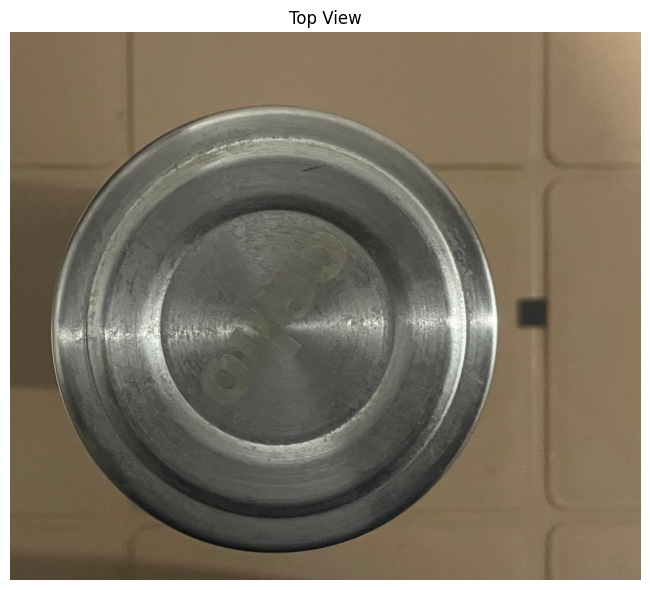

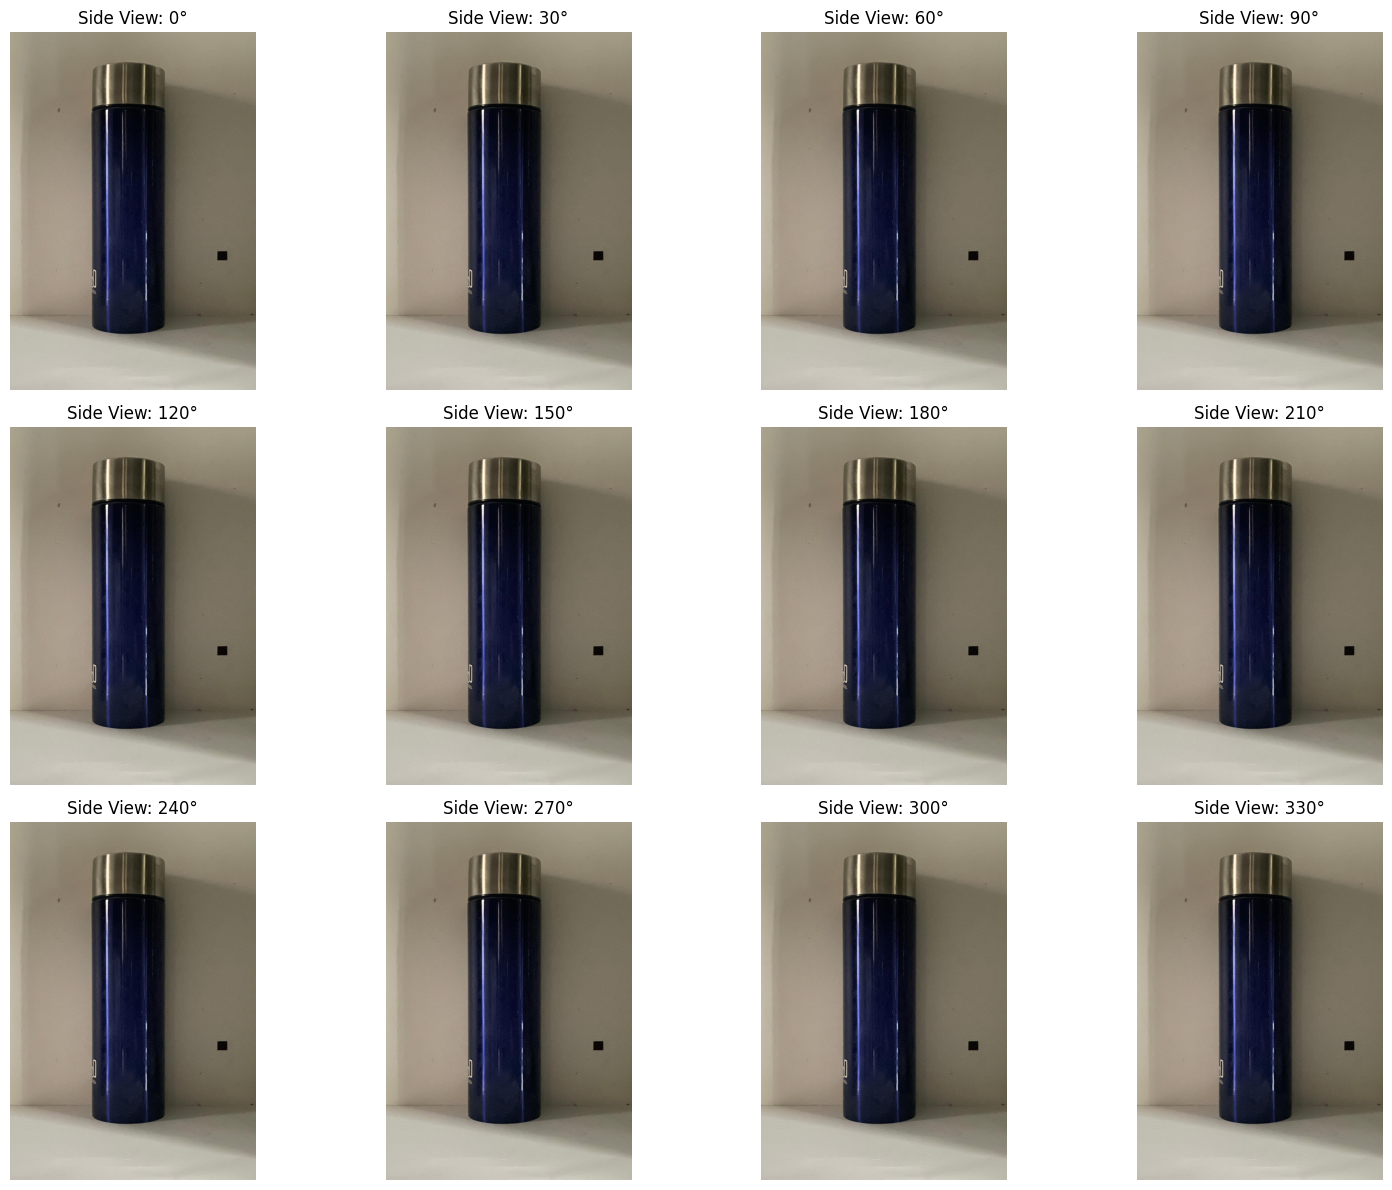

Top view loaded: True
Number of side views loaded: 12


In [99]:
import os
import cv2
import matplotlib.pyplot as plt

# ----------------------------
# Image paths
# ----------------------------
top_view_path = IMAGE_PATH + "Top_view.jpeg"

side_view_paths = [
    IMAGE_PATH + "Image_0.jpeg",
    IMAGE_PATH + "Image_30.jpeg",
    IMAGE_PATH + "Image_60.jpeg",
    IMAGE_PATH + "Image_90.jpeg",
    IMAGE_PATH + "Image_120.jpeg",
    IMAGE_PATH + "Image_150.jpeg",
    IMAGE_PATH + "Image_180.jpeg",
    IMAGE_PATH + "Image_210.jpeg",
    IMAGE_PATH + "Image_240.jpeg",
    IMAGE_PATH + "Image_270.jpeg",
    IMAGE_PATH + "Image_300.jpeg",
    IMAGE_PATH + "Image_330.jpeg",
]

side_view_angles = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]

# ----------------------------
# Load top view
# ----------------------------
top_view = cv2.imread(top_view_path)

if top_view is None:
    print(f"Error: Could not load top-view image from {top_view_path}")
else:
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(top_view, cv2.COLOR_BGR2RGB))
    plt.title("Top View")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# ----------------------------
# Load side views
# ----------------------------
side_views = []
valid_side_view_paths = []
valid_side_view_angles = []

for i, path in enumerate(side_view_paths):
    img = cv2.imread(path)
    if img is None:
        print(f"Warning: Could not load {path}")
        continue
    side_views.append(img)
    valid_side_view_paths.append(path)
    valid_side_view_angles.append(side_view_angles[i])

if len(side_views) == 0:
    print("Error: No side-view images loaded.")
else:
    n = len(side_views)
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, img in enumerate(side_views):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Side View: {valid_side_view_angles[i]}°")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

print(f"Top view loaded: {top_view is not None}")
print(f"Number of side views loaded: {len(side_views)}")

In [100]:
def detect_reference_square(img, debug=False, filename=""):
    """
    Detect 1x1 black square marker.

    Automatically restricts search to the right 40% of the image
    if 'top' is found in the filename (e.g. top_view.jpeg).
    Otherwise searches the full image.

    Returns:
        scale_cm_per_px, pixel_size, bbox=(x,y,w,h), center=(cx,cy)
    """
    REAL_SIZE_CM = 1.0
    H, W = img.shape[:2]

    right40_only = "top" in os.path.basename(filename).lower()

    if right40_only:
        x_search0 = int(0.60 * W)
        search_img = img[:, x_search0:]
    else:
        x_search0 = 0
        search_img = img

    gray = cv2.cvtColor(search_img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    _, thresh = cv2.threshold(blur, 80, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidates = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 20:
            continue

        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.03 * peri, True)
        if len(approx) != 4:
            continue

        x, y, w, h = cv2.boundingRect(approx)
        if h == 0:
            continue

        ar = w / h
        if not (0.75 <= ar <= 1.25):
            continue

        rect = cv2.minAreaRect(cnt)
        (_, _), (rw, rh), _ = rect
        if rw <= 0 or rh <= 0:
            continue

        px_size = (rw + rh) / 2.0
        fill_ratio = area / max(w * h, 1)
        score = area - 200 * abs(1 - ar) + 100 * fill_ratio

        candidates.append((score, x, y, w, h, px_size, cnt, approx))

    if not candidates:
        if right40_only:
            raise ValueError("Reference square not found in right 40% of image.")
        else:
            raise ValueError("Reference square not found.")

    candidates.sort(reverse=True, key=lambda t: t[0])
    _, x, y, w, h, px_size, cnt, approx = candidates[0]

    x_full = x + x_search0
    approx_full = approx.copy()
    approx_full[:, 0, 0] += x_search0

    scale = REAL_SIZE_CM / px_size
    cx = x_full + w / 2.0
    cy = y + h / 2.0

    if debug:
        vis = img.copy()

        if right40_only:
            cv2.rectangle(vis, (x_search0, 0), (W - 1, H - 1), (255, 255, 0), 2)

        cv2.drawContours(vis, [approx_full], -1, (0, 255, 0), 3)
        cv2.rectangle(vis, (x_full, y), (x_full + w, y + h), (255, 0, 0), 2)
        cv2.putText(
            vis,
            f"ref {px_size:.1f}px",
            (x_full, max(20, y - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

        plt.figure(figsize=(8, 6))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(f"Reference square | scale={scale:.5f} cm/px")
        plt.axis("off")
        plt.show()

    return scale, px_size, (x_full, y, w, h), (cx, cy)


def segment_object_general(img, ref_bbox=None, debug=False, view_name="view"):
    """
    More robust segmentation than plain Canny.
    Uses background-distance + GrabCut refinement.
    Works much better for weird shapes.
    """
    h, w = img.shape[:2]
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    # Exclude reference square from background model
    valid = np.ones((h, w), dtype=bool)
    if ref_bbox is not None:
        x, y, bw, bh = ref_bbox
        pad = int(max(bw, bh) * 0.25)
        x0 = max(0, x - pad)
        y0 = max(0, y - pad)
        x1 = min(w, x + bw + pad)
        y1 = min(h, y + bh + pad)
        valid[y0:y1, x0:x1] = False

    # Border pixels = likely background
    border = np.zeros((h, w), dtype=bool)
    m = max(10, int(0.06 * min(h, w)))
    border[:m, :] = True
    border[-m:, :] = True
    border[:, :m] = True
    border[:, -m:] = True

    bg_mask = border & valid
    bg_pixels = lab[bg_mask]
    if len(bg_pixels) == 0:
        raise ValueError("Not enough background pixels for segmentation.")

    bg_med = np.median(bg_pixels, axis=0)
    dist = np.linalg.norm(lab.astype(np.float32) - bg_med[None, None, :], axis=2)

    dist_u8 = cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, init = cv2.threshold(dist_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Remove reference square area
    if ref_bbox is not None:
        x, y, bw, bh = ref_bbox
        pad = int(max(bw, bh) * 0.2)
        x0 = max(0, x - pad)
        y0 = max(0, y - pad)
        x1 = min(w, x + bw + pad)
        y1 = min(h, y + bh + pad)
        init[y0:y1, x0:x1] = 0

    kernel = np.ones((5, 5), np.uint8)
    init = cv2.morphologyEx(init, cv2.MORPH_OPEN, kernel)
    init = cv2.morphologyEx(init, cv2.MORPH_CLOSE, kernel)

    # GrabCut refinement
    gc_mask = np.full((h, w), cv2.GC_PR_BGD, np.uint8)
    gc_mask[border] = cv2.GC_BGD

    sure_fg = cv2.erode(init, np.ones((7, 7), np.uint8), iterations=1)
    probable_fg = cv2.dilate(init, np.ones((9, 9), np.uint8), iterations=1)

    gc_mask[probable_fg > 0] = cv2.GC_PR_FGD
    gc_mask[sure_fg > 0] = cv2.GC_FGD

    if ref_bbox is not None:
        gc_mask[y0:y1, x0:x1] = cv2.GC_BGD

    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)

    cv2.grabCut(img, gc_mask, None, bgdModel, fgdModel, 4, cv2.GC_INIT_WITH_MASK)

    mask = np.where(
        (gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD), 255, 0
    ).astype(np.uint8)

    # Clean up
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8))
    mask = ndimage.binary_fill_holes(mask > 0).astype(np.uint8) * 255

    # Keep best connected component
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels <= 1:
        raise ValueError(f"No segmented object found for {view_name}")

    img_cx = w / 2
    img_cy = h / 2

    best_label = None
    best_score = -1e18
    for lab_id in range(1, num_labels):
        area = stats[lab_id, cv2.CC_STAT_AREA]
        x = stats[lab_id, cv2.CC_STAT_LEFT]
        y = stats[lab_id, cv2.CC_STAT_TOP]
        bw = stats[lab_id, cv2.CC_STAT_WIDTH]
        bh = stats[lab_id, cv2.CC_STAT_HEIGHT]
        cx, cy = centroids[lab_id]

        border_touch = int(x == 0 or y == 0 or x + bw >= w or y + bh >= h)
        center_penalty = 0.002 * ((cx - img_cx) ** 2 + (cy - img_cy) ** 2)
        score = area - 50000 * border_touch - center_penalty

        if score > best_score:
            best_score = score
            best_label = lab_id

    mask = np.where(labels == best_label, 255, 0).astype(np.uint8)

    ys, xs = np.where(mask > 0)
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()

    contour = max(
        cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0],
        key=cv2.contourArea
    )

    result = {
        "mask": mask,
        "bbox": (x0, y0, x1, y1),
        "centroid_px": (xs.mean(), ys.mean()),
        "bottom_px": np.percentile(ys, 99.5),
        "top_px": np.percentile(ys, 0.5),
        "left_px": np.percentile(xs, 0.5),
        "right_px": np.percentile(xs, 99.5),
        "contour": contour
    }

    if debug:
        vis = img.copy()
        cv2.drawContours(vis, [contour], -1, (0, 255, 0), 2)
        cv2.rectangle(vis, (x0, y0), (x1, y1), (255, 0, 0), 2)

        fig, ax = plt.subplots(1, 3, figsize=(18, 5))
        ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax[0].set_title(f"{view_name}: original")
        ax[0].axis("off")

        ax[1].imshow(dist_u8, cmap="gray")
        ax[1].set_title(f"{view_name}: bg-distance")
        ax[1].axis("off")

        ax[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax[2].set_title(f"{view_name}: final mask")
        ax[2].axis("off")
        plt.tight_layout()
        plt.show()

    return result

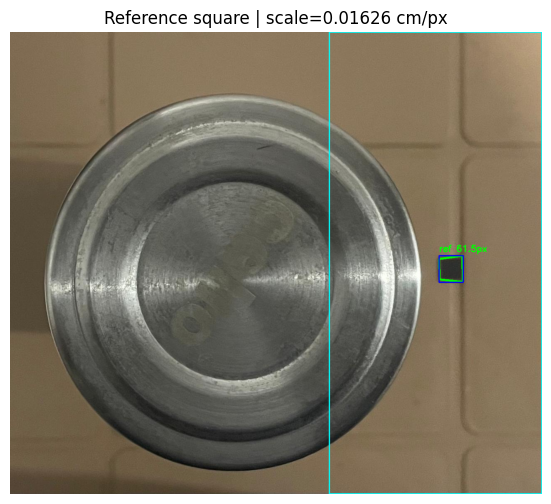

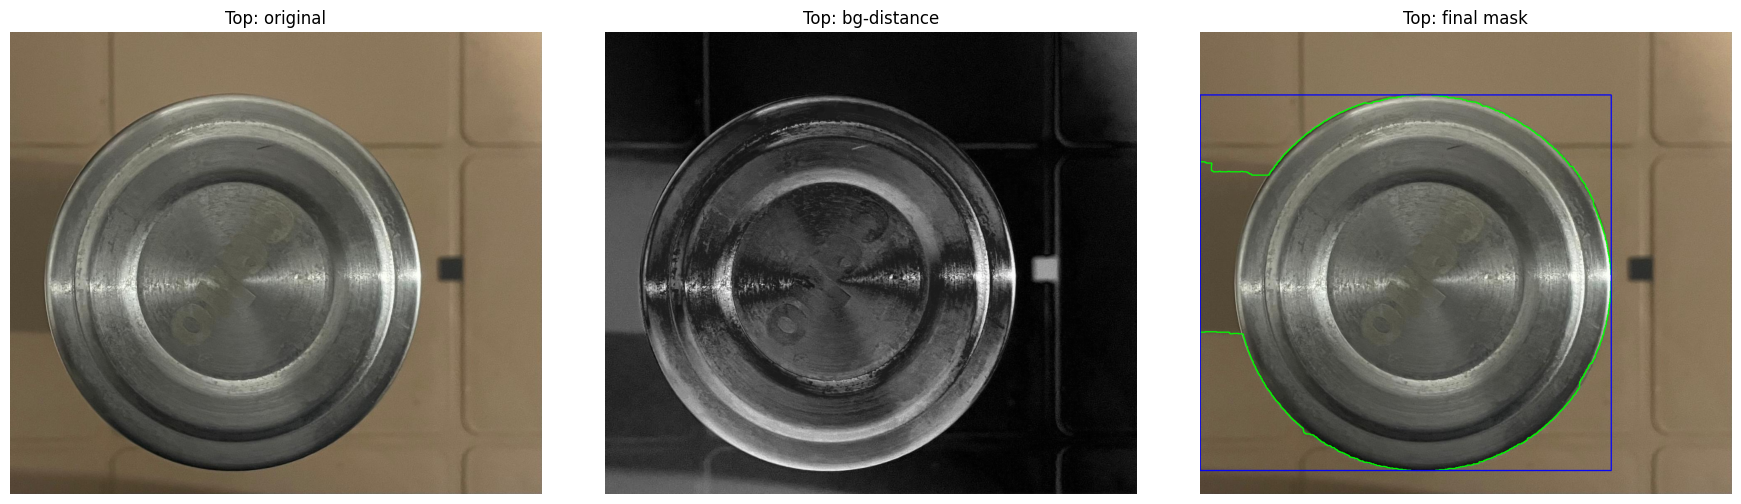

Top scale: 0.016260 cm/px

Processing side view 0°
scale = 0.028986 cm/px

Processing side view 30°
scale = 0.028986 cm/px

Processing side view 60°
scale = 0.028986 cm/px

Processing side view 90°
scale = 0.028986 cm/px

Processing side view 120°
scale = 0.028986 cm/px

Processing side view 150°
scale = 0.028986 cm/px

Processing side view 180°
scale = 0.028986 cm/px

Processing side view 210°
scale = 0.028986 cm/px

Processing side view 240°
scale = 0.028986 cm/px

Processing side view 270°
scale = 0.028986 cm/px

Processing side view 300°
scale = 0.028986 cm/px

Processing side view 330°
scale = 0.028986 cm/px

Loaded side views: 12
Mean side scale: 0.028985507246376815


In [101]:
# ----------------------------
# Top image
# ----------------------------
top_scale_cm, top_ref_px, top_ref_bbox, top_ref_center = detect_reference_square(top_view, debug=DEBUG, filename="top_view.jpeg")
top_seg = segment_object_general(top_view, ref_bbox=top_ref_bbox, debug=DEBUG, view_name="Top")

print(f"Top scale: {top_scale_cm:.6f} cm/px")

# ----------------------------
# Side images
# ----------------------------
side_infos = []

for img, ang in zip(side_views, valid_side_view_angles):
    print(f"\nProcessing side view {ang}°")

    scale_cm, ref_px, ref_bbox, ref_center = detect_reference_square(img, debug=False)
    seg = segment_object_general(img, ref_bbox=ref_bbox, debug=False, view_name=f"Side {ang}")

    side_infos.append({
        "angle_deg": ang,
        "scale_cm": scale_cm,
        "ref_px": ref_px,
        "ref_bbox": ref_bbox,
        "seg": seg
    })

    print(f"scale = {scale_cm:.6f} cm/px")

print("\nLoaded side views:", len(side_infos))
print("Mean side scale:", np.mean([s["scale_cm"] for s in side_infos]))

In [102]:
def build_visual_hull(top_seg, top_scale_cm, side_infos, voxel_cm=0.15, angle_offset_deg=0.0, debug=True):
    top_mask = top_seg["mask"] > 0
    top_h, top_w = top_mask.shape
    top_cx, top_cy = top_seg["centroid_px"]

    ys, xs = np.where(top_mask)
    x_min_cm = (xs.min() - top_cx) * top_scale_cm
    x_max_cm = (xs.max() - top_cx) * top_scale_cm
    y_min_cm = -(ys.max() - top_cy) * top_scale_cm
    y_max_cm = -(ys.min() - top_cy) * top_scale_cm

    z_max_cm = 0.0
    for s in side_infos:
        height_cm = (s["seg"]["bottom_px"] - s["seg"]["top_px"]) * s["scale_cm"]
        z_max_cm = max(z_max_cm, height_cm)

    pad = voxel_cm * 2
    x_vals = np.arange(x_min_cm - pad, x_max_cm + pad, voxel_cm)
    y_vals = np.arange(y_min_cm - pad, y_max_cm + pad, voxel_cm)
    z_vals = np.arange(0.0, z_max_cm + pad, voxel_cm)

    nx, ny, nz = len(x_vals), len(y_vals), len(z_vals)
    occ = np.ones((nx, ny, nz), dtype=bool)

    print(f"Grid: {nx} x {ny} x {nz} = {nx*ny*nz:,} voxels")

    # ---- Diagnostic: print per-view cx and bottom BEFORE using them ----
    all_cx     = [(s["seg"]["left_px"] + s["seg"]["right_px"]) / 2.0 for s in side_infos]
    all_bottom = [s["seg"]["bottom_px"] for s in side_infos]
    all_scales = [s["scale_cm"] for s in side_infos]

    print("\n--- Per-view alignment diagnostics ---")
    for s, cx, bot in zip(side_infos, all_cx, all_bottom):
        print(f"  {s['angle_deg']:3d}°  cx={cx:.1f}px  bottom={bot:.1f}px  scale={s['scale_cm']:.5f}")

    # KEY FIX: use median cx and bottom across all views
    # Per-view values fluctuate by ~5-20px due to segmentation noise.
    # Even 5px error in cx at 0.023 cm/px = 0.11 cm shift per view.
    # Across 12 views this causes the intersection to collapse or bloat.
    global_cx     = float(np.median(all_cx))
    global_bottom = float(np.median(all_bottom))
    global_scale  = float(np.median(all_scales))

    print(f"\nPer-view cx     range: [{min(all_cx):.1f}, {max(all_cx):.1f}]  → using median: {global_cx:.1f}")
    print(f"Per-view bottom range: [{min(all_bottom):.1f}, {max(all_bottom):.1f}]  → using median: {global_bottom:.1f}")
    print(f"Per-view scale  range: [{min(all_scales):.5f}, {max(all_scales):.5f}]  → using median: {global_scale:.5f}")

    # Flag suspicious views
    cx_std     = np.std(all_cx)
    bottom_std = np.std(all_bottom)
    print(f"\ncx std={cx_std:.1f}px  bottom std={bottom_std:.1f}px")
    if cx_std > 15:
        print("  WARNING: cx std > 15px — object may not be centered consistently across shots")
    if bottom_std > 10:
        print("  WARNING: bottom std > 10px — object base height is inconsistent, check segmentation")

    # ---- Top view constraint (vectorized) ----
    XX, YY = np.meshgrid(np.arange(nx), np.arange(ny), indexing="ij")
    u_top = np.round(top_cx + x_vals[XX] / top_scale_cm).astype(int)
    v_top = np.round(top_cy - y_vals[YY] / top_scale_cm).astype(int)
    valid_top = (u_top >= 0) & (u_top < top_w) & (v_top >= 0) & (v_top < top_h)
    in_top = np.zeros((nx, ny), dtype=bool)
    in_top[valid_top] = top_mask[v_top[valid_top], u_top[valid_top]]
    occ[~in_top, :] = False
    print(f"\n  After top view:  {occ.sum():,} voxels")

    # ---- Side view constraints (vectorized, using global cx and bottom) ----
    X3, Y3, Z3 = np.meshgrid(x_vals, y_vals, z_vals, indexing="ij")

    for s in side_infos:
        angle = np.deg2rad(s["angle_deg"] + angle_offset_deg)
        c, ss = np.cos(angle), np.sin(angle)
        mask = s["seg"]["mask"] > 0
        h, w = mask.shape

        # Use global_cx and global_bottom instead of per-view values
        # Use per-view scale (it's genuinely calibrated per image)
        scale_side = s["scale_cm"]

        u = np.round(global_cx + (X3 * c + Y3 * ss) / scale_side).astype(int)
        v = np.round(global_bottom - Z3 / scale_side).astype(int)

        valid = (u >= 0) & (u < w) & (v >= 0) & (v < h)
        inside = np.zeros((nx, ny, nz), dtype=bool)
        inside[valid] = mask[v[valid], u[valid]]
        occ &= inside

        n = occ.sum()
        print(f"  After {s['angle_deg']:3d}° side: {n:,} voxels")
        if n == 0:
            raise ValueError(
                f"Visual hull empty after {s['angle_deg']}°.\n"
                "  Things to try:\n"
                "  1. Set debug=True on segment_object_general for this view and check mask\n"
                "  2. Try angle_offset_deg=90 or 180\n"
                "  3. Increase voxel_cm to 0.3 to see if grid resolution is the issue"
            )

    volume_cm3 = occ.sum() * (voxel_cm ** 3)

    filled = np.argwhere(occ)
    if len(filled) == 0:
        raise ValueError("Visual hull is empty.")

    x_extent = (filled[:, 0].max() - filled[:, 0].min() + 1) * voxel_cm
    y_extent = (filled[:, 1].max() - filled[:, 1].min() + 1) * voxel_cm
    z_extent = (filled[:, 2].max() - filled[:, 2].min() + 1) * voxel_cm

    result = {
        "occ": occ,
        "x_vals": x_vals, "y_vals": y_vals, "z_vals": z_vals,
        "voxel_cm": voxel_cm,
        "volume_cm3": volume_cm3,
        "width_cm": x_extent,
        "depth_cm": y_extent,
        "height_cm": z_extent
    }

    if debug:
        print("\n--- Visual Hull Reconstruction ---")
        print(f"Voxel size:  {voxel_cm:.3f} cm")
        print(f"Grid size:   {occ.shape}")
        print(f"Volume:      {volume_cm3:.4f} cm^3")
        print(f"Width:       {x_extent:.3f} cm")
        print(f"Depth:       {y_extent:.3f} cm")
        print(f"Height:      {z_extent:.3f} cm")

    return result

In [103]:
vh = build_visual_hull(
    top_seg=top_seg,
    top_scale_cm=top_scale_cm,
    side_infos=side_infos,
    voxel_cm=VOXEL_SIZE_CM,
    angle_offset_deg=ANGLE_OFFSET_DEG,
    debug=True
)

print(f"\nEstimated volume: {vh['volume_cm3']:.4f} cm^3")
print(f"Estimated width:  {vh['width_cm']:.3f} cm")
print(f"Estimated depth:  {vh['depth_cm']:.3f} cm")
print(f"Estimated height: {vh['height_cm']:.3f} cm")

Grid: 112 x 102 x 186 = 2,124,864 voxels

--- Per-view alignment diagnostics ---
    0°  cx=439.5px  bottom=1070.0px  scale=0.02899
   30°  cx=439.5px  bottom=1070.0px  scale=0.02899
   60°  cx=440.5px  bottom=1070.0px  scale=0.02899
   90°  cx=440.5px  bottom=1070.0px  scale=0.02899
  120°  cx=439.5px  bottom=1070.0px  scale=0.02899
  150°  cx=439.5px  bottom=1070.0px  scale=0.02899
  180°  cx=439.5px  bottom=1070.0px  scale=0.02899
  210°  cx=439.5px  bottom=1070.0px  scale=0.02899
  240°  cx=439.5px  bottom=1070.0px  scale=0.02899
  270°  cx=439.5px  bottom=1070.0px  scale=0.02899
  300°  cx=439.5px  bottom=1070.0px  scale=0.02899
  330°  cx=445.5px  bottom=1070.0px  scale=0.02899

Per-view cx     range: [439.5, 445.5]  → using median: 439.5
Per-view bottom range: [1070.0, 1070.0]  → using median: 1070.0
Per-view scale  range: [0.02899, 0.02899]  → using median: 0.02899

cx std=1.6px  bottom std=0.0px

  After top view:  1,502,322 voxels
  After   0° side: 850,097 voxels
  After  30

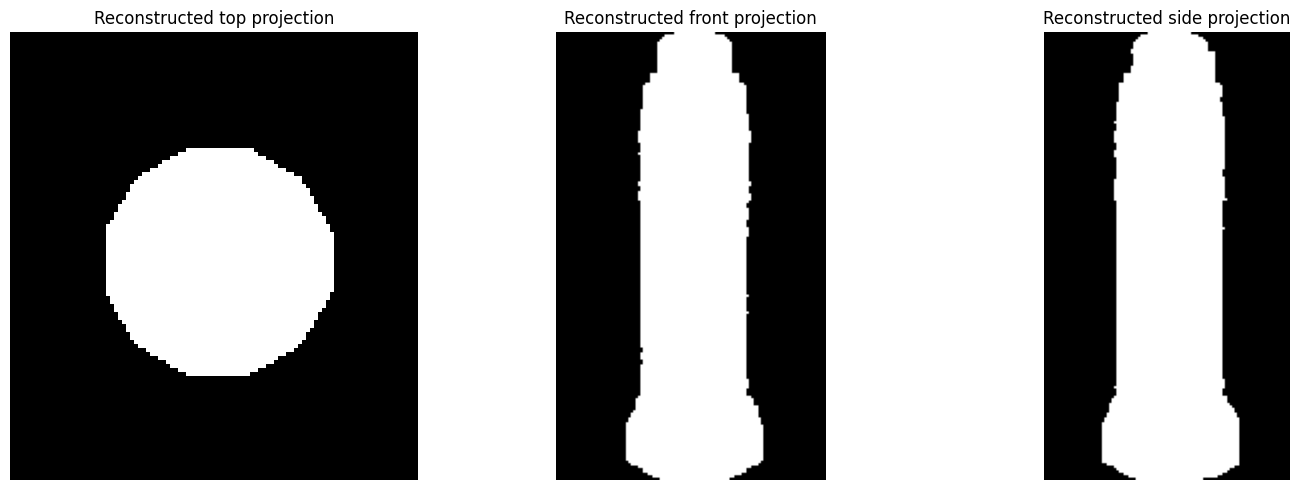

In [104]:
occ = vh["occ"]

proj_top = occ.any(axis=2).astype(np.uint8) * 255
proj_front = occ.any(axis=1).astype(np.uint8) * 255   # x-z
proj_side = occ.any(axis=0).astype(np.uint8) * 255    # y-z

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(proj_top, cmap="gray")
ax[0].set_title("Reconstructed top projection")
ax[0].axis("off")

ax[1].imshow(proj_front.T, cmap="gray", origin="lower")
ax[1].set_title("Reconstructed front projection")
ax[1].axis("off")

ax[2].imshow(proj_side.T, cmap="gray", origin="lower")
ax[2].set_title("Reconstructed side projection")
ax[2].axis("off")

plt.tight_layout()
plt.show()

#### Weight + Density

In [105]:
weight = 4000  # grams

In [106]:
density = weight / vh['volume_cm3']  # g/cm^3
print(f"Estimated Density: {density:.4f} g/cm^3")

Estimated Density: 3.9507 g/cm^3


#### Purity Analysis

In [107]:
# Method 1: Using the polynomial formula
def density_to_karat_formula(D):
    """Calculate karat from density using polynomial formula"""
    K = 0.0089 * D**3 - 0.550 * D**2 + 12.5299 * D - 77.06
    return K

# Method 2: Density ranges for different karats
karat_density_ranges = {
    24: (19.31, 19.51),
    22: (17.45, 18.24),
    20: (16.03, 17.11),
    18: (14.84, 16.12),
    14: (12.91, 14.44),
    10: (11.42, 13.09)
}

# Calculate karat using formula
karat_from_formula = density_to_karat_formula(density)

print("=" * 60)
print("PURITY ANALYSIS RESULTS")
print("=" * 60)
print(f"\nMeasured Density: {density:.4f} g/cm³")
print(f"\nMethod 1 - Polynomial Formula:")
print(f"  Estimated Karat: {karat_from_formula:.2f}K")

# Find closest match in density ranges
print(f"\nMethod 2 - Density Range Classification:")
found_match = False
for karat, (min_d, max_d) in sorted(karat_density_ranges.items(), reverse=True):
    if min_d <= density <= max_d:
        print(f"  ✓ Matches K{karat} range ({min_d} - {max_d} g/cm³)")
        found_match = True
        break

if not found_match:
    # Find closest range
    closest_karat = None
    min_distance = float('inf')
    for karat, (min_d, max_d) in karat_density_ranges.items():
        mid_d = (min_d + max_d) / 2
        distance = abs(density - mid_d)
        if distance < min_distance:
            min_distance = distance
            closest_karat = karat
    
    if closest_karat:
        min_d, max_d = karat_density_ranges[closest_karat]
        if density < min_d:
            print(f"  → Below K{closest_karat} range (closest: {min_d} - {max_d} g/cm³)")
        else:
            print(f"  → Above K{closest_karat} range (closest: {min_d} - {max_d} g/cm³)")

print("=" * 60)

PURITY ANALYSIS RESULTS

Measured Density: 3.9507 g/cm³

Method 1 - Polynomial Formula:
  Estimated Karat: -35.59K

Method 2 - Density Range Classification:
  → Below K10 range (closest: 11.42 - 13.09 g/cm³)


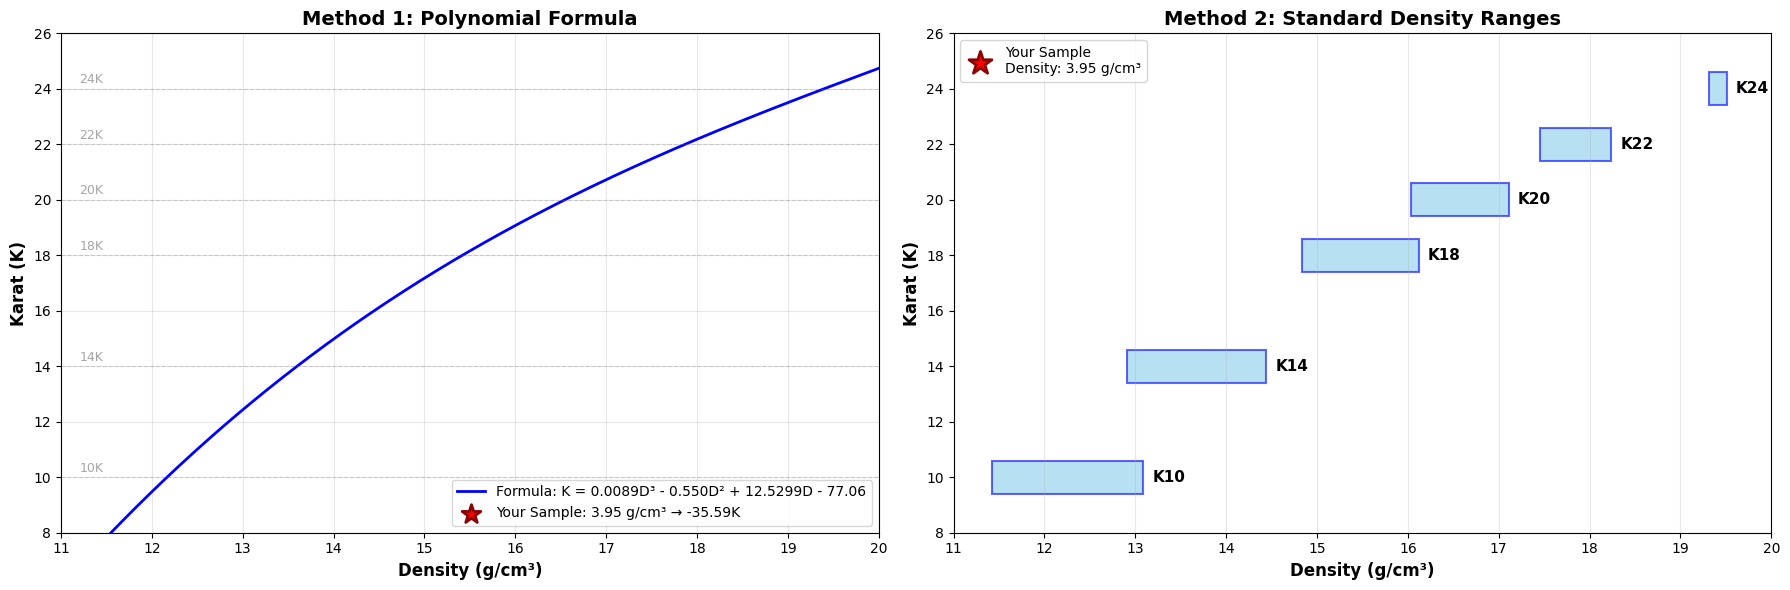


📊 Visualization complete! Both methods are displayed above.


In [108]:
# Create visualization of density-karat relationship
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Polynomial Formula Curve
densities_range = np.linspace(11, 20, 500)
karats_formula = [density_to_karat_formula(d) for d in densities_range]

ax1.plot(densities_range, karats_formula, 'b-', linewidth=2, label='Formula: K = 0.0089D³ - 0.550D² + 12.5299D - 77.06')
ax1.scatter([density], [karat_from_formula], color='red', s=200, zorder=5, marker='*', 
            edgecolors='darkred', linewidth=2, label=f'Your Sample: {density:.2f} g/cm³ → {karat_from_formula:.2f}K')

# Add horizontal lines for standard karats
for k in [10, 14, 18, 20, 22, 24]:
    ax1.axhline(y=k, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
    ax1.text(11.2, k + 0.2, f'{k}K', fontsize=9, color='gray', alpha=0.7)

ax1.set_xlabel('Density (g/cm³)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Karat (K)', fontsize=12, fontweight='bold')
ax1.set_title('Method 1: Polynomial Formula', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best', fontsize=10)
ax1.set_xlim(11, 20)
ax1.set_ylim(8, 26)

# Plot 2: Density Range Classification
karat_values = sorted(karat_density_ranges.keys())
min_densities = [karat_density_ranges[k][0] for k in karat_values]
max_densities = [karat_density_ranges[k][1] for k in karat_values]
mid_densities = [(karat_density_ranges[k][0] + karat_density_ranges[k][1]) / 2 for k in karat_values]

# Plot density ranges as horizontal bars
for i, karat in enumerate(karat_values):
    min_d, max_d = karat_density_ranges[karat]
    ax2.barh(karat, max_d - min_d, left=min_d, height=1.2, 
             alpha=0.6, color='skyblue', edgecolor='blue', linewidth=1.5)
    ax2.text(max_d + 0.1, karat, f'K{karat}', fontsize=11, va='center', fontweight='bold')

# Plot sample point
ax2.scatter([density], [karat_from_formula], color='red', s=300, zorder=5, marker='*',
            edgecolors='darkred', linewidth=2, label=f'Your Sample\nDensity: {density:.2f} g/cm³')

# Add vertical line for sample density
ax2.axvline(x=density, color='red', linestyle='--', alpha=0.5, linewidth=2)

ax2.set_xlabel('Density (g/cm³)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Karat (K)', fontsize=12, fontweight='bold')
ax2.set_title('Method 2: Standard Density Ranges', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
ax2.legend(loc='best', fontsize=10)
ax2.set_xlim(11, 20)
ax2.set_ylim(8, 26)

plt.tight_layout()
plt.show()

print("\n📊 Visualization complete! Both methods are displayed above.")